# Application to Real-World Temporal Data

In our final experiment, we apply MCbiF to temporal sequences of partitions computed from realworld contact data of free-ranging house mice. This data captures the changes in the social network structure of the rodents over time (Bovet et al., 2022).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

from mcbif import MultiscaleClusteringBifiltration as MCbiF
from sankey import Sankey

In [55]:
# We set a global configuration for matplotlib to obtain well-readable plots
SMALL_SIZE = 15
MEDIUM_SIZE = 15
BIGGER_SIZE = 15

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Load flow stability partitions

We load the publicly available flow stability partitions dataset.

In [3]:
import json

In [4]:
# load flow stabililty data available at https://dataverse.harvard.edu/file.xhtml?fileId=5657692
with open('data/wild_mice_flow_stability_clustering.json') as file:
    clustering_data = json.load(file)

In [5]:
# unpack flow stability data
tau_w = []
partitions_forward_per_week = []
partitions_backward_per_week = []
NVI_forward_per_week = []
NVI_backward_per_week = []

for i in range(9): # don't load results for largest tau as is outlier
    tau_w.append(clustering_data[i]["tau_w"])
    partitions_forward_per_week.append(clustering_data[i]["partitions_forward_per_week"])
    partitions_backward_per_week.append(clustering_data[i]["partitions_backward_per_week"])
    NVI_forward_per_week.append(clustering_data[i]["NVI_forward_per_week"])
    NVI_backward_per_week.append(clustering_data[i]["NVI_backward_per_week"])

In [6]:
# define weeks
weeks = np.arange(9)

### Process mice data

We start by processing the mice data.

In [7]:
# extract noedes per week
nodes_per_week = [set(sum(partitions_forward_per_week[0][week],[])) for week in weeks]

# compute intersection of nodes
intersection_nodes = np.array(list(set.intersection(*nodes_per_week)), dtype=int)
n_intersection_nodes = len(intersection_nodes)

# get ids of nodes in intersection
intersection_nodes_to_id = {node: i for i, node in enumerate(intersection_nodes)}

In [8]:
def reassign_cluster_ids(partition_id):
    """ Reassign cluster ids to be consecutive integers starting from 0."""
    cluster_id_old = np.unique(partition_id)
    # Create a mapping from old cluster ids to new cluster ids
    cluster_id_mapping = {old_id: new_id for new_id, old_id in enumerate(cluster_id_old)}
    # Apply the mapping to the partition_id
    partition_id_new = np.array([cluster_id_mapping[id] for id in partition_id])
    return partition_id_new

In [9]:
def get_partition(partitions_unprocessed, i):
    """Restrict partitions to nodes in intersection and reassign cluster ids. 
    Returns partition indicator vector."""
    partitions = []
    for week in weeks:
        partition_id = np.zeros(n_intersection_nodes, dtype=int)
        for id, cluster in enumerate(partitions_unprocessed[i][week]):
            for node in cluster:
                if node in intersection_nodes_to_id:
                    # Assign the cluster id to the corresponding intersection node
                    partition_id[intersection_nodes_to_id[node]] = id
        # Reassign cluster ids to be consecutive integers starting from 0
        partition_id = reassign_cluster_ids(partition_id)
        partitions.append(partition_id)
    return partitions


In [10]:
# Obtain sequences of partitions for forward and backward partitions for different tau
partitions_forward = []
partitions_backward = []
for i in range(len(tau_w)):
    partitions_forward.append(get_partition(partitions_forward_per_week, i))
    partitions_backward.append(get_partition(partitions_backward_per_week, i))

### Number of clusters

We first evaluate the number of clusters in the different paritions.

In [11]:
tau_names = ["0.1 s", "1 s", "8 s", "60 s", "1 h", "5 h", "8 h", "24 h", "7 d"]

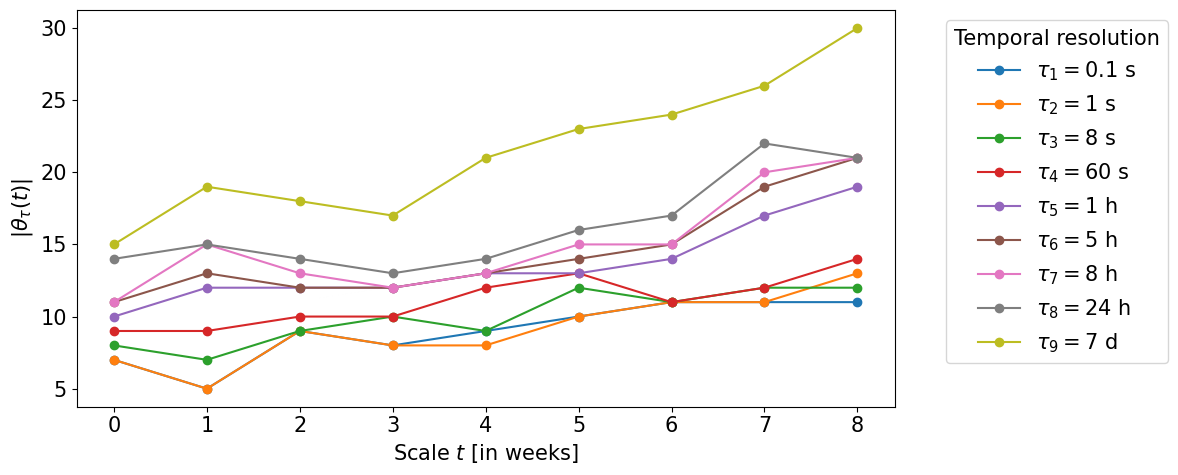

In [12]:

fig, ax = plt.subplots(figsize=(12, 5))
fig.subplots_adjust(right=0.75)
for i in range(len(tau_w)):
    label = r"$\tau$" + f"$_{i+1}=$" + f"{tau_names[i]}"
    ax.plot(np.max(np.array(partitions_forward[i]),axis=1), label=label, marker='o')
ax.set(xlabel=f'Scale $t$ [in weeks]', ylabel=r'$|\theta_\tau(t)|$') #, title='Number of clusters over weeks for different tau')
title = r"Temporal resolution"
ax.legend(title=title, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("figures/wild_mice_n_clusters.pdf", bbox_inches="tight")



## Sankey plotting

We use the OmicsSankey package to plot optimised Sankey diagrams for (forward) sequences of partitions at the optimal $\tau$ selected by Bovet et al.

In [13]:
# initialise Sankey
sankey_2 = Sankey(partitions=partitions_forward[1])

# optimise Sankey
sankey_2.compute_omics_sankey(stage1_iter=1500,stage2_iter=1500) 

OmicsSankey - Stage 1


100%|██████████| 1500/1500 [00:01<00:00, 1378.50it/s]


OmicsSankey - Stage 2


100%|██████████| 1500/1500 [00:06<00:00, 249.13it/s]


In [14]:
# plot Sankey
fig = sankey_2.plot_sankey(pad=9,thickness=4)
fig.write_image(f"figures/sankey_forward_omics_1_v2.svg")

In [15]:
# initialise Sankey
sankey_4 = Sankey(partitions=partitions_forward[3])

# optimise Sankey
sankey_4.compute_omics_sankey(stage1_iter=1500,stage2_iter=1500) 

OmicsSankey - Stage 1


100%|██████████| 1500/1500 [00:01<00:00, 1287.09it/s]


OmicsSankey - Stage 2


100%|██████████| 1500/1500 [00:07<00:00, 200.14it/s]


In [16]:
# plot Sankey
fig = sankey_4.plot_sankey(pad=11,thickness=4)
fig.write_image(f"figures/sankey_forward_omics_3_v2.svg")

In [17]:
# initialise Sankey
sankey_8 = Sankey(partitions=partitions_forward[7])

# optimise Sankey
sankey_8.compute_omics_sankey(stage1_iter=3000,stage2_iter=3000) 

OmicsSankey - Stage 1


100%|██████████| 3000/3000 [00:04<00:00, 730.47it/s]


OmicsSankey - Stage 2


100%|██████████| 3000/3000 [00:35<00:00, 83.85it/s]


In [18]:
# plot Sankey
fig = sankey_8.plot_sankey(pad=8,thickness=4)
fig.write_image(f"figures/sankey_forward_omics_7_v2.svg")

## MCbif computations

We apply MCbiF to the flow stability sequences of partitions, where we select the weeks as our scale $t$. Different values of $\tau$ lead to different sequences of partitions index by $t$, see Bovet et al. for details.

### Timing

We first compute the computing time of the standard MCbiF.

In [51]:
import time  # Import the time module

timing_standard = []
n_simplices_standard = []

for i in tqdm(range(len(tau_w))):
    start_time = time.time()  # Start timing
    
    mcbif = MCbiF()
    mcbif.load_data(partitions_forward[i], weeks + 1)
    mcbif.build_filtration(tqdm_disable=True)
    n_simplices_standard.append(mcbif.n_simplices)
    mcbif.compute_persistence(dimensions=[0, 1], tqdm_disable=True)
    
    end_time = time.time()  # End timing
    iteration_time = end_time - start_time  # Calculate elapsed time
    timing_standard.append(iteration_time)  # Add the time to the timing list

print("Total compute time:", sum(timing_standard))
print("Number of simplices:", np.mean(n_simplices_standard))

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:33<00:00,  3.67s/it]

Total compute time: 33.020395278930664
Number of simplices: 116700.66666666667


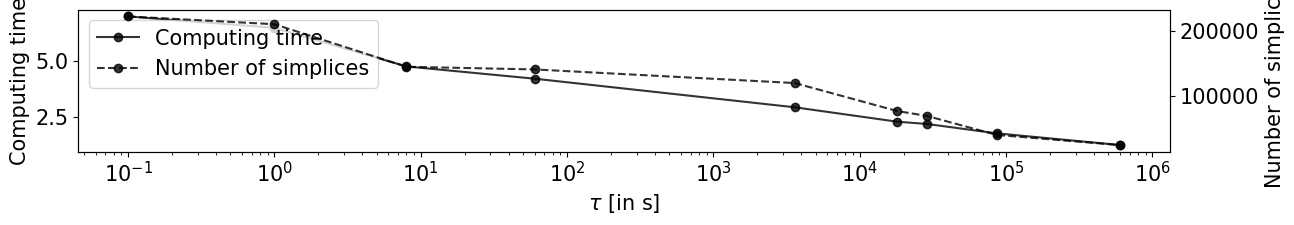

In [56]:
fig, ax = plt.subplots(figsize=(13, 2.5))

ax.plot(tau_w, timing_standard, marker='o', label=r"Computing time", alpha=0.8, color="black")
ax2 = ax.twinx()
ax2.set(ylabel=r"Number of simplices")
ax2.plot(tau_w, n_simplices_standard, label=r"Number of simplices", marker='o', alpha=0.8, color="black", ls="--")
ax.set(xscale='log', xlabel=r'$\tau$ [in s]', ylabel=r"Computing time")
ax.legend()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("figures/persistent_conflict_forward.svg", bbox_inches="tight")

We next evaluate the computing time of the nerve-based MCbiF.

In [52]:
import time  # Import the time module

timing_nerve = []
n_simplices_nerve = []

for i in range(len(tau_w)):
    start_time = time.time()  # Start timing
    
    mcbif = MCbiF(method="nerve")
    mcbif.load_data(partitions_forward[i], weeks + 1)
    mcbif.build_filtration(tqdm_disable=True)
    n_simplices_nerve.append(mcbif.n_simplices)
    mcbif.compute_persistence(dimensions=[0, 1], tqdm_disable=True)
    
    end_time = time.time()  # End timing
    iteration_time = end_time - start_time  # Calculate elapsed time
    timing_nerve.append(iteration_time)  # Add the time to the timing list

print("Total compute time:", sum(timing_nerve))
print("Number of simplices:", np.mean(n_simplices_nerve))

Total compute time: 0.6822066307067871
Number of simplices: 262.77777777777777


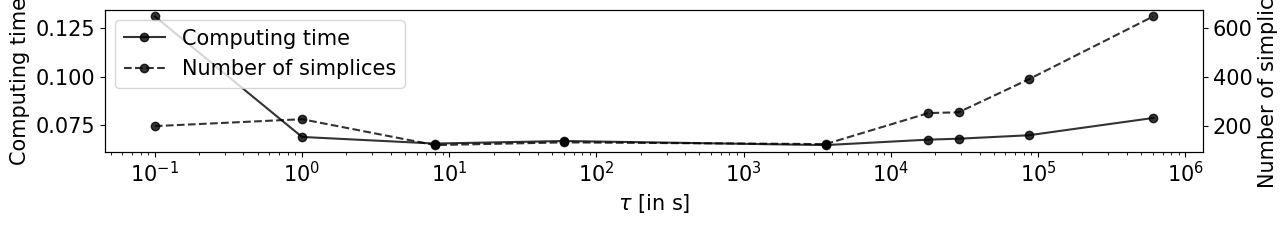

In [57]:
fig, ax = plt.subplots(figsize=(13, 2.5))

ax.plot(tau_w, timing_nerve, marker='o', label=r"Computing time", alpha=0.8, color="black")
ax2 = ax.twinx()
ax2.set(ylabel=r"Number of simplices")
ax2.plot(tau_w, n_simplices_nerve, label=r"Number of simplices", marker='o', alpha=0.8, color="black", ls="--")
ax.set(xscale='log', xlabel=r'$\tau$ [in s]', ylabel=r"Computing time")
ax.legend()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("figures/persistent_conflict_forward.svg", bbox_inches="tight")

We observe a 50-fold reduction time due to a much lower number of simplices.

In [59]:
33/0.68

48.52941176470588

### Forward

We compute the MCbiF and its Hilbert functions for the forward sequences of partitions first.

In [46]:
# We set a global configuration for matplotlib to obtain well-readable plots
SMALL_SIZE = 30
MEDIUM_SIZE = 30
BIGGER_SIZE = 30

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


Processing forward partitions for tau_w = 0.1 ...

Average 0-conflict: 0.311


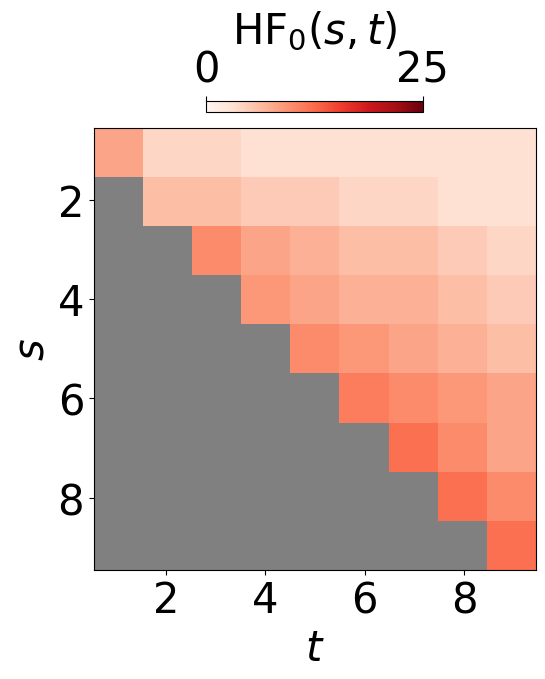

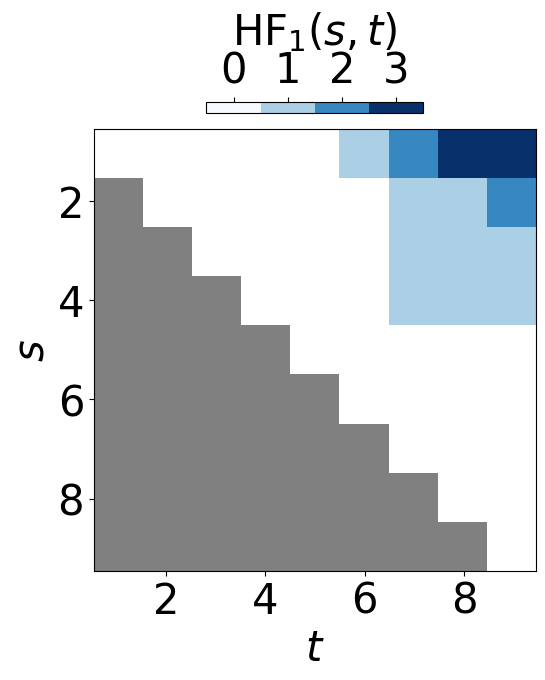


Processing forward partitions for tau_w = 1.0 ...

Average 0-conflict: 0.314


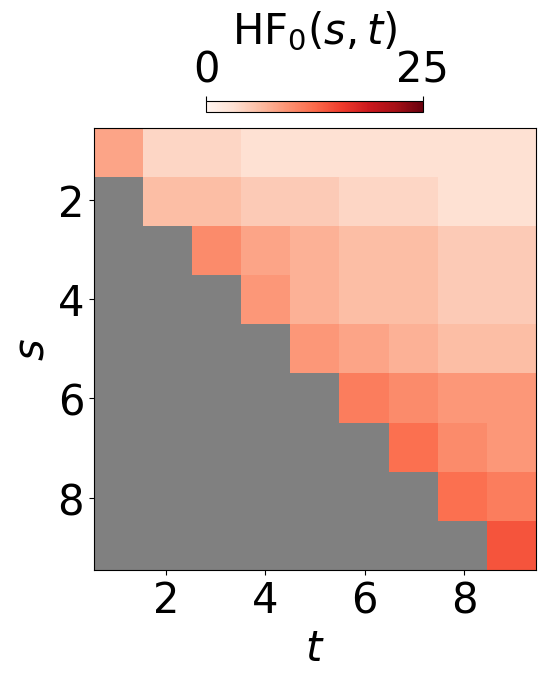

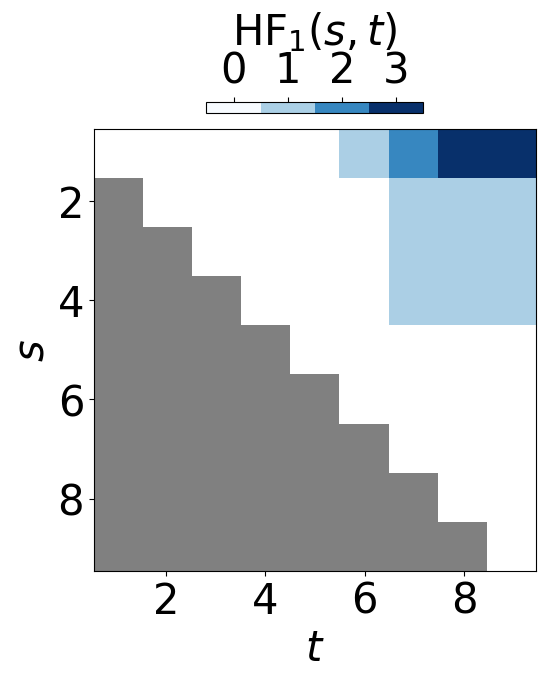


Processing forward partitions for tau_w = 8.0 ...

Average 0-conflict: 0.112


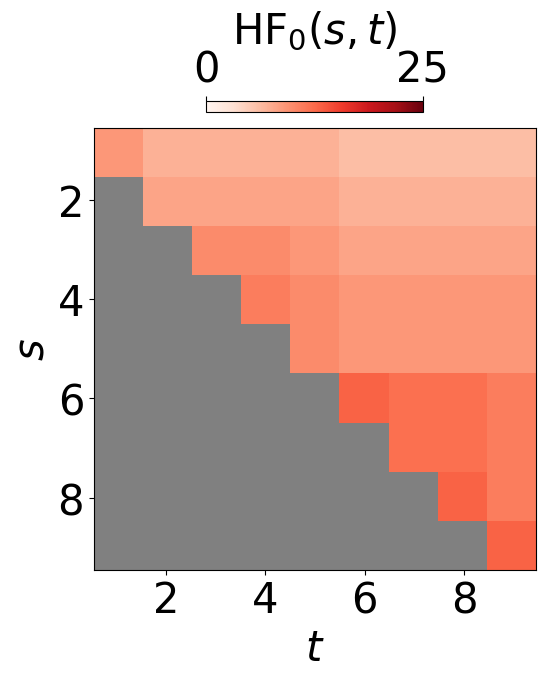

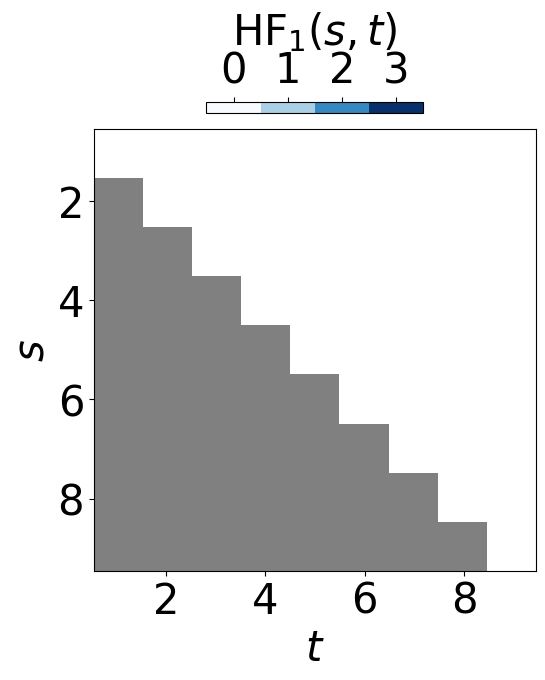


Processing forward partitions for tau_w = 60.0 ...

Average 0-conflict: 0.115


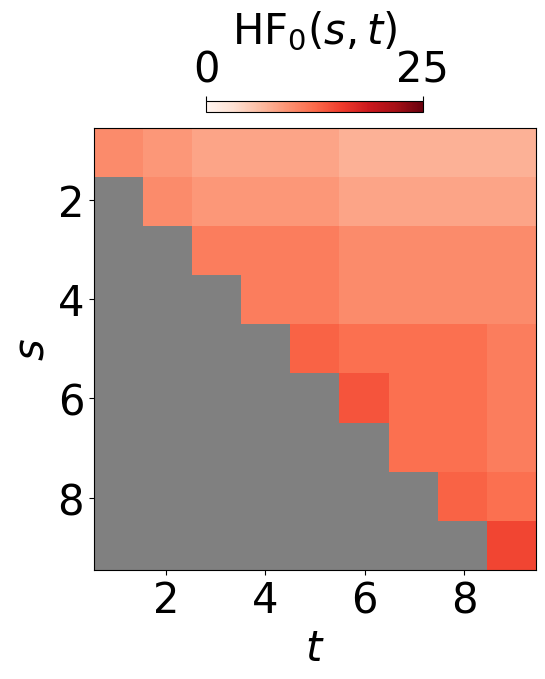

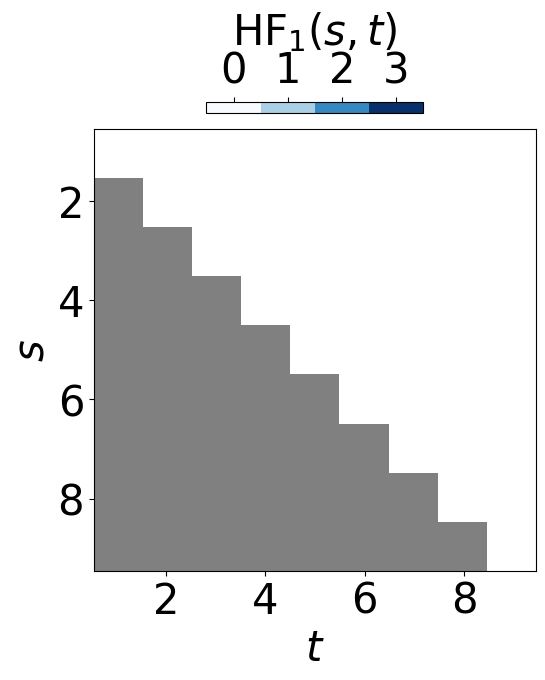


Processing forward partitions for tau_w = 3600.0 ...

Average 0-conflict: 0.112


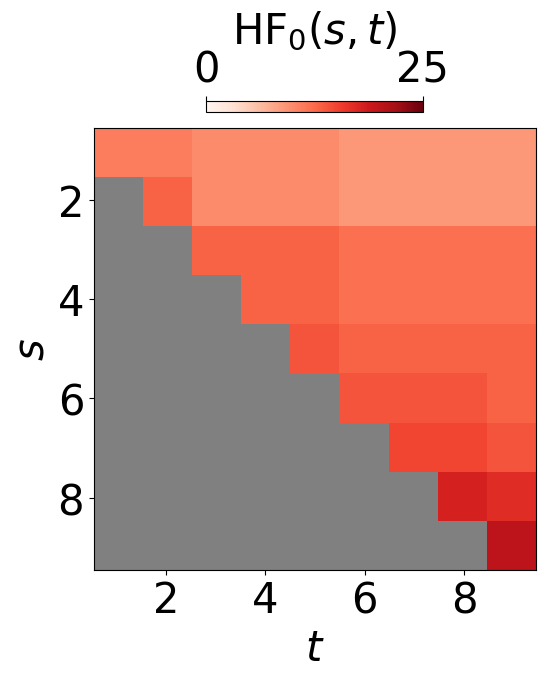

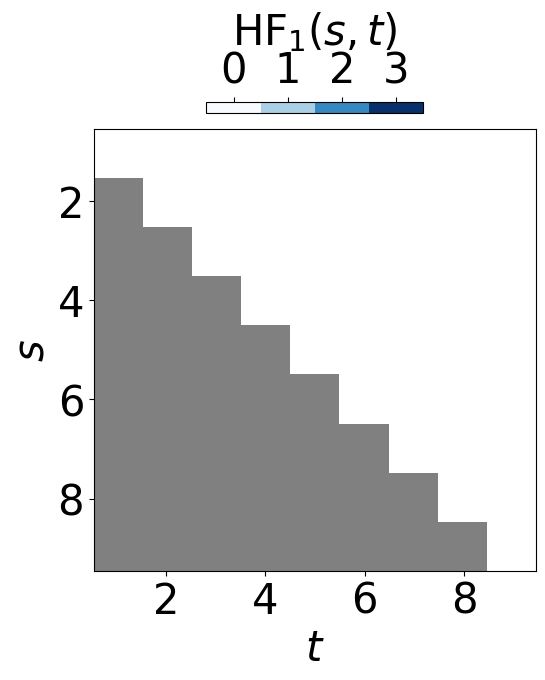


Processing forward partitions for tau_w = 18000.0 ...

Average 0-conflict: 0.134


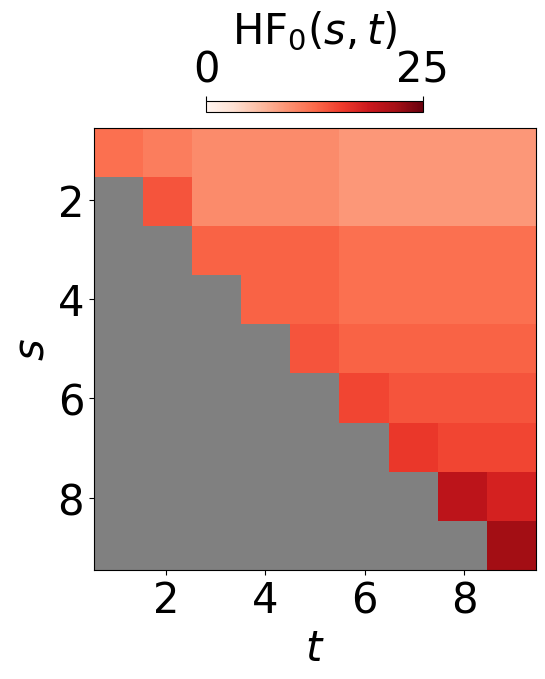

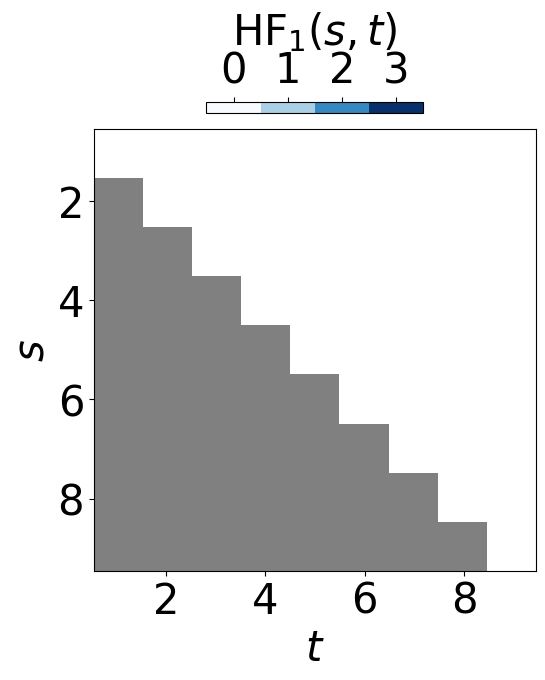


Processing forward partitions for tau_w = 28800.0 ...

Average 0-conflict: 0.124


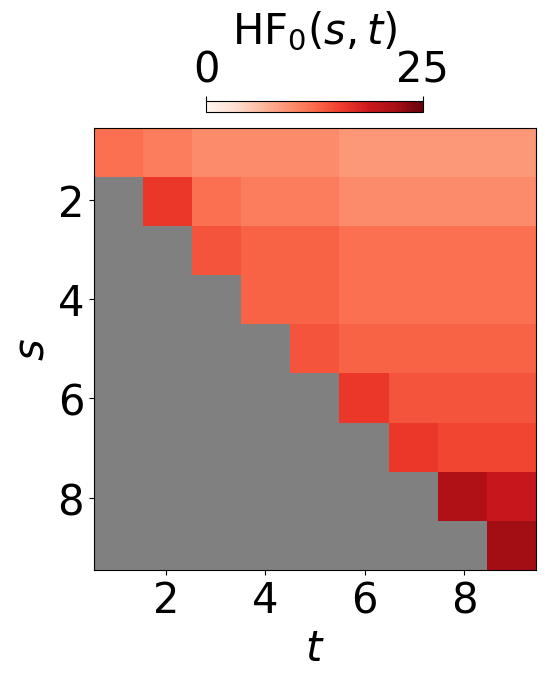

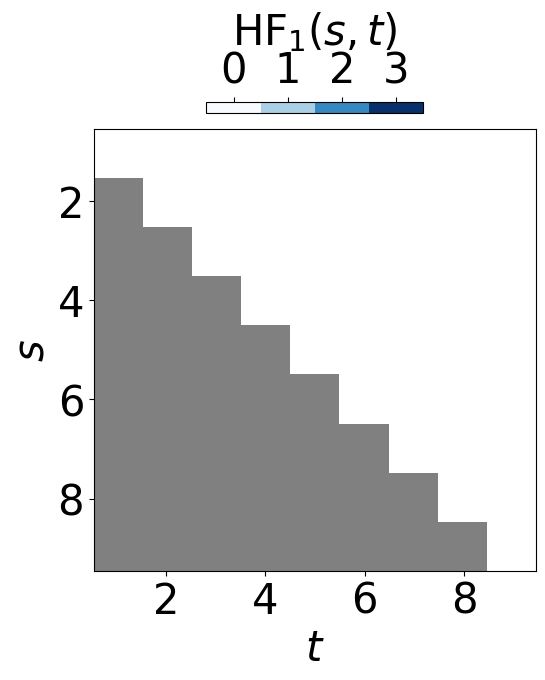


Processing forward partitions for tau_w = 86400.0 ...

Average 0-conflict: 0.146


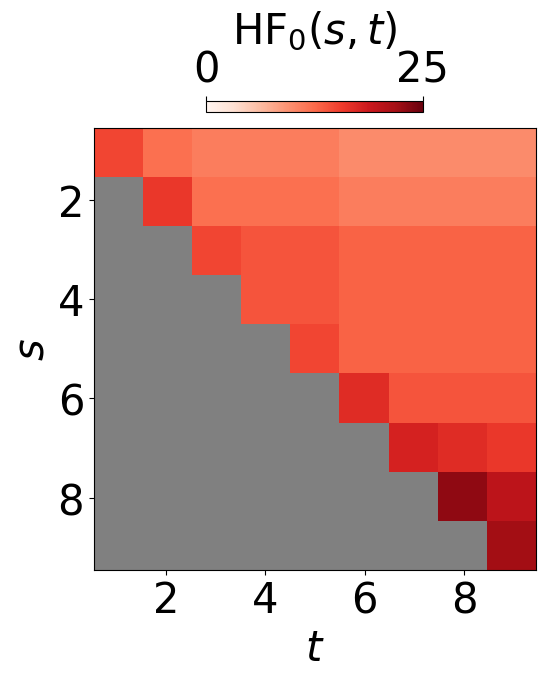

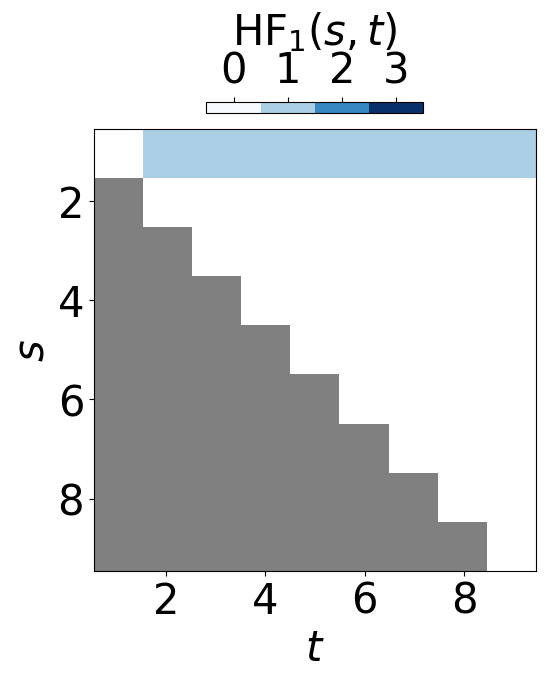


Processing forward partitions for tau_w = 604800.0 ...

Average 0-conflict: 0.287


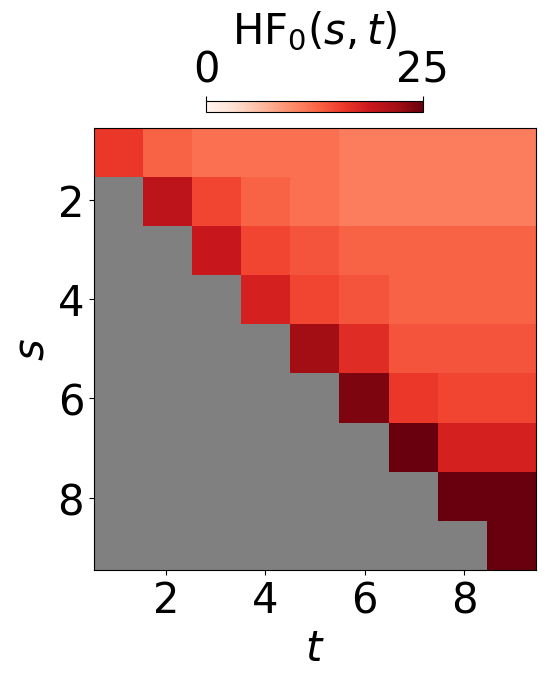

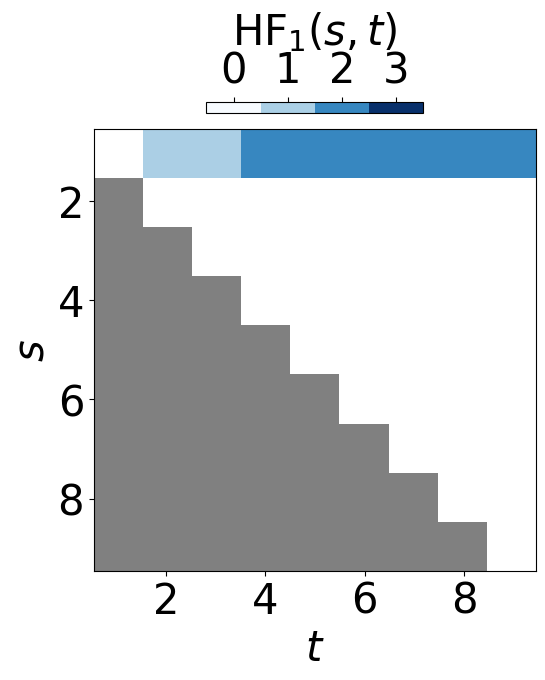

In [47]:
mcbif_results_forward = []

for i in range(len(tau_w)):

    print(f"\nProcessing forward partitions for tau_w = {tau_w[i]} ...")
    # initialise MCbiF
    mcbif = MCbiF(method="nerve")
    mcbif.load_data(partitions_forward[i], weeks+1)

    # run MCbiF
    mcbif_results_forward.append(mcbif.compute_all_measures(file_path=None, tqdm_disable=True))
    print("\nAverage 0-conflict:", round(mcbif.conflict_0_avg,3))

    # make plots
    mcbif.plot_hilbert_function(0, path=f"figures/hf0_forward_{i}.png", vmax=25.1)
    # mcbif.plot_conflict_0()
    mcbif.plot_hilbert_function(1, path=f"figures/hf1_forward_{i}.png", discrete_ticks=np.arange(0,4))
    # mcbif.plot_conflict_1_diff()
    plt.show()


### Backward

We compute the MCbiF and its Hilbert functions also for the backward sequences of partitions.


Processing backward partitions for tau_w = 0.1 ...

Average 0-conflict: 0.446


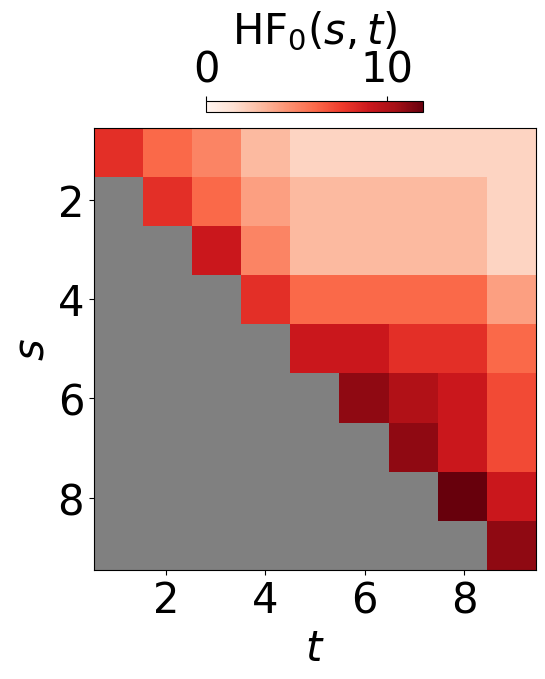

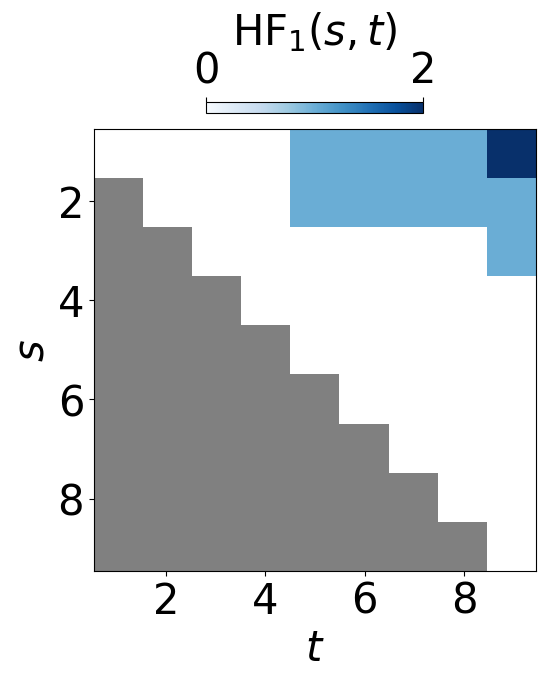


Processing backward partitions for tau_w = 1.0 ...

Average 0-conflict: 0.444


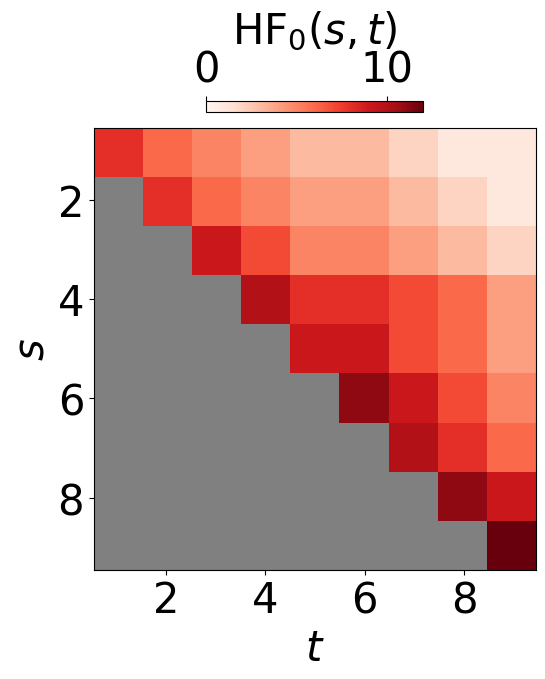

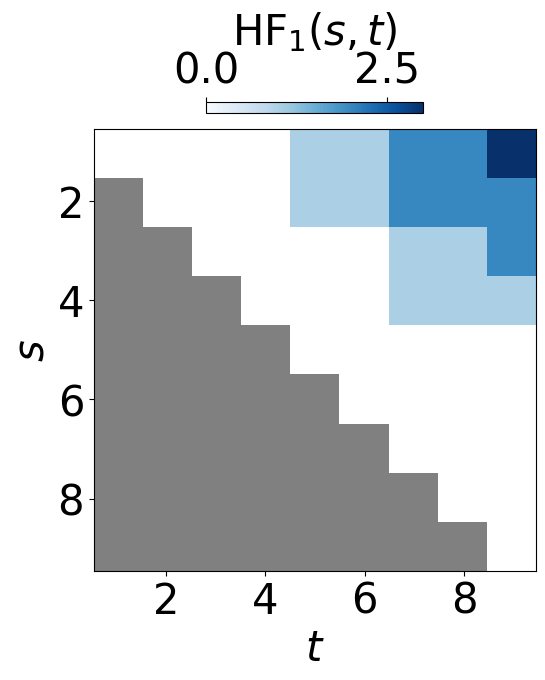


Processing backward partitions for tau_w = 8.0 ...

Average 0-conflict: 0.191


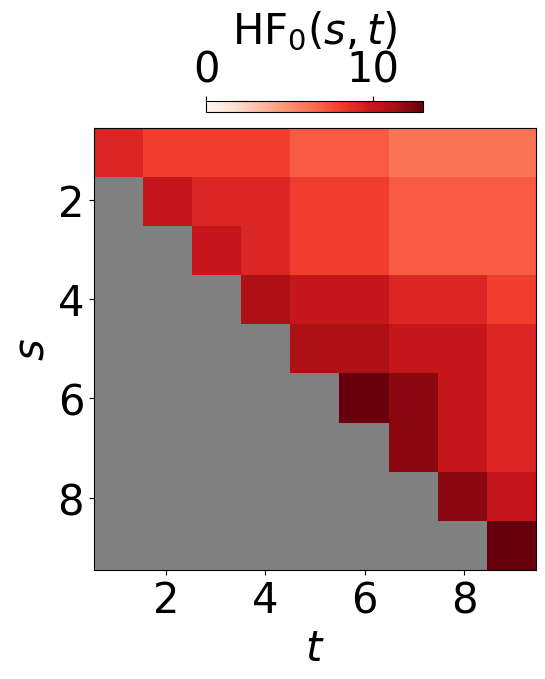

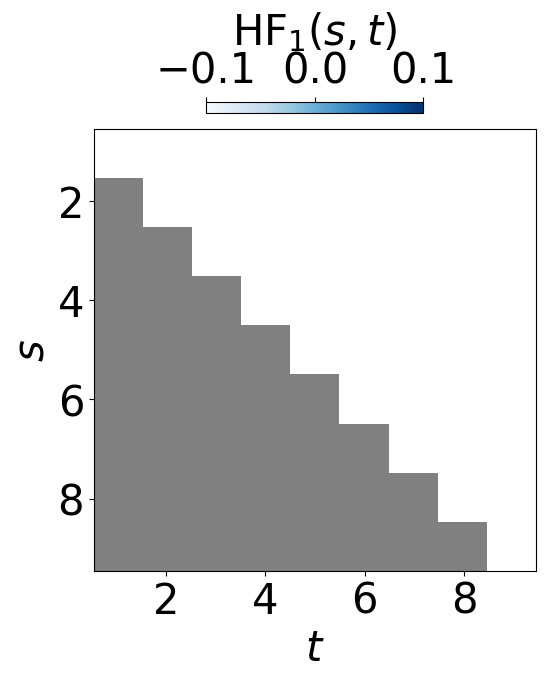


Processing backward partitions for tau_w = 60.0 ...

Average 0-conflict: 0.134


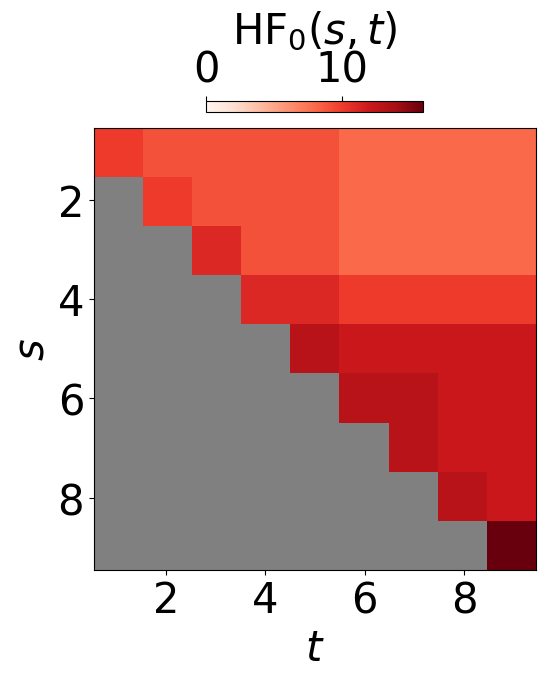

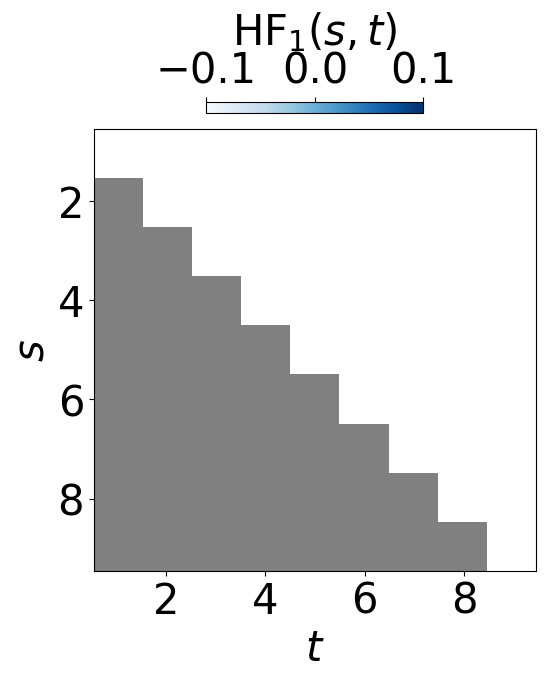


Processing backward partitions for tau_w = 3600.0 ...

Average 0-conflict: 0.116


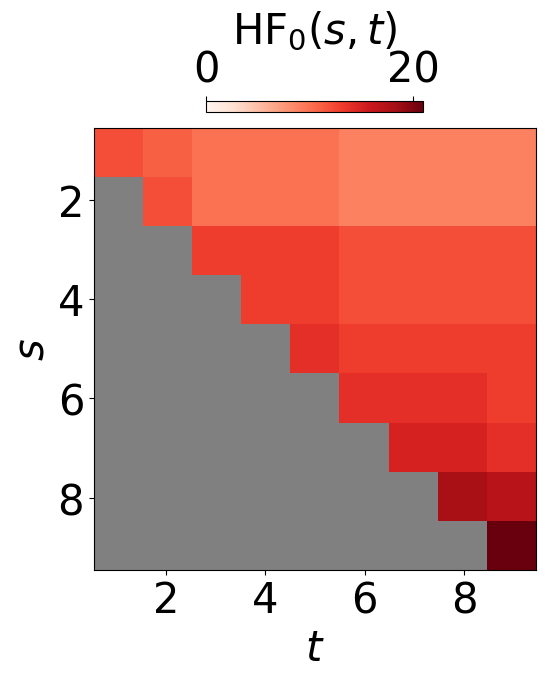

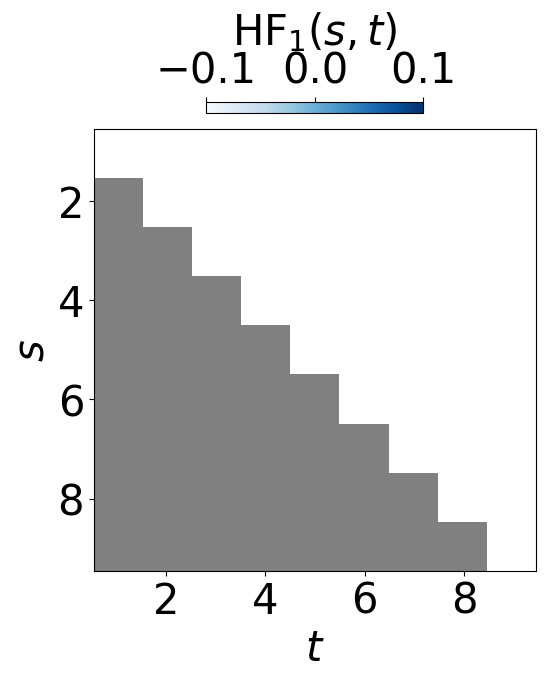


Processing backward partitions for tau_w = 18000.0 ...

Average 0-conflict: 0.104


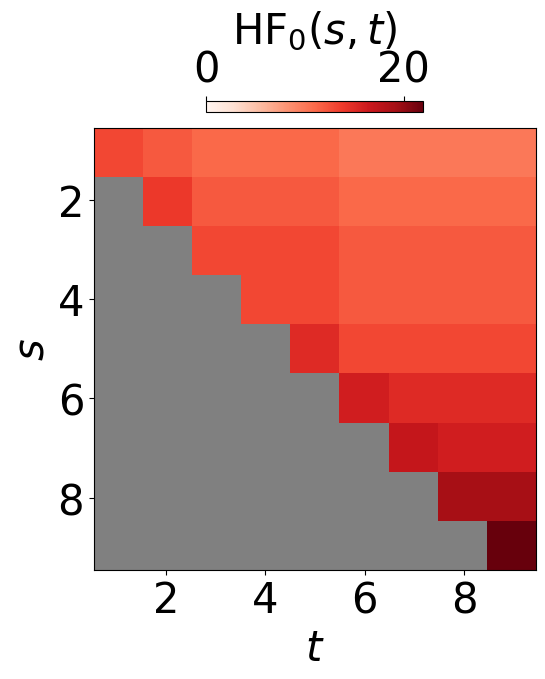

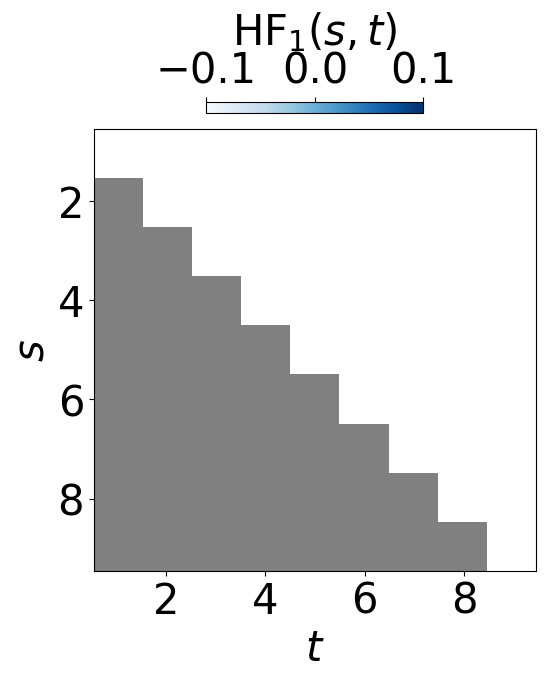


Processing backward partitions for tau_w = 28800.0 ...

Average 0-conflict: 0.102


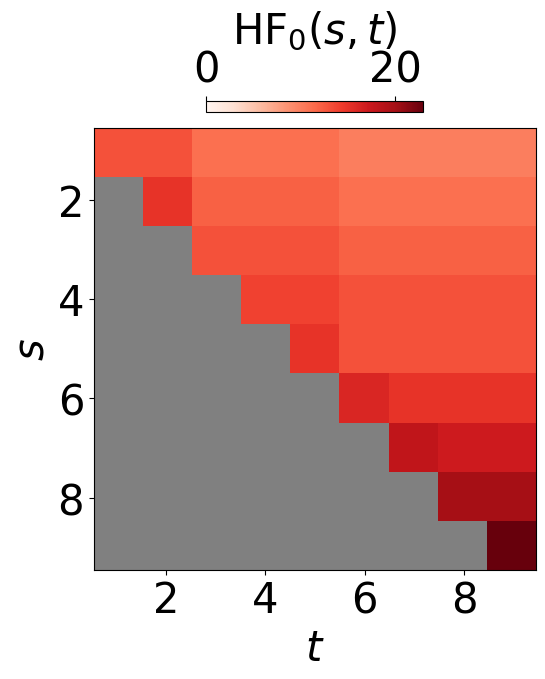

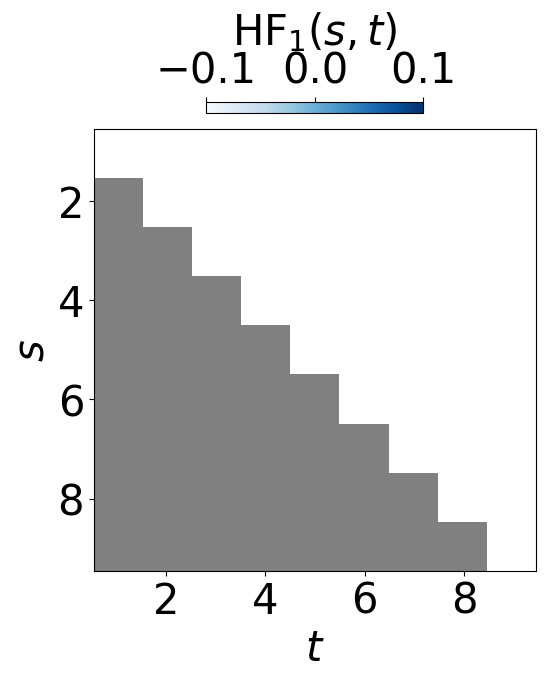


Processing backward partitions for tau_w = 86400.0 ...

Average 0-conflict: 0.103


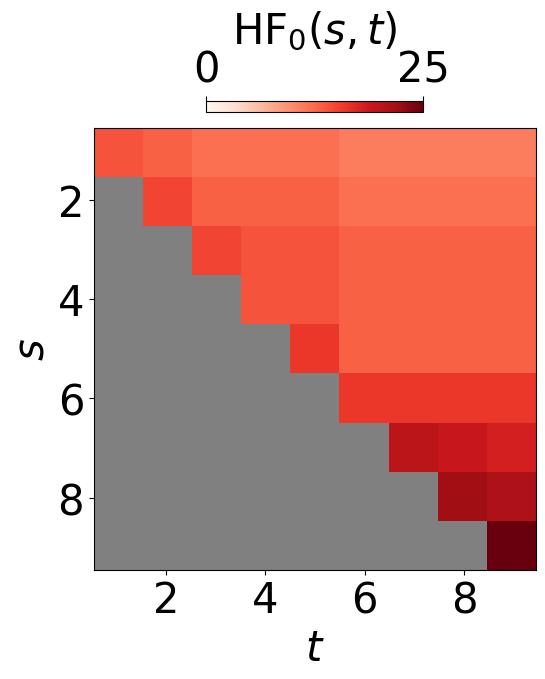

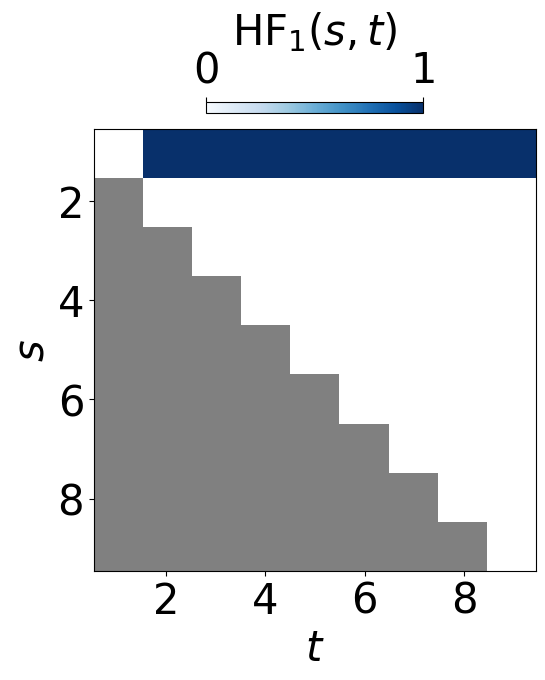


Processing backward partitions for tau_w = 604800.0 ...

Average 0-conflict: 0.229


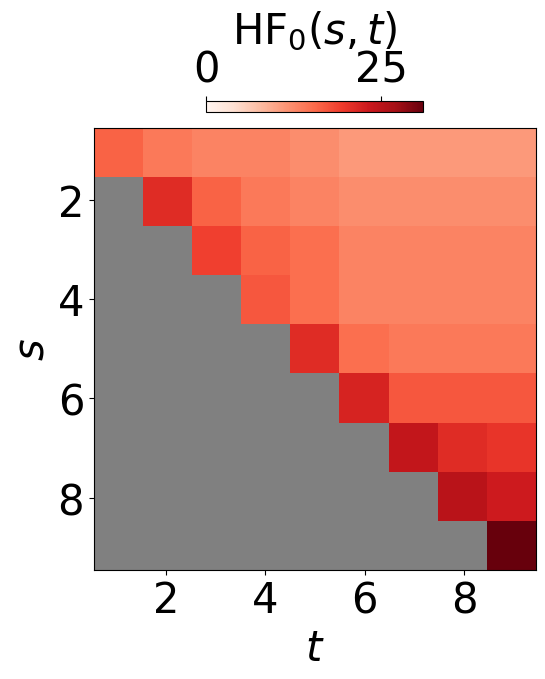

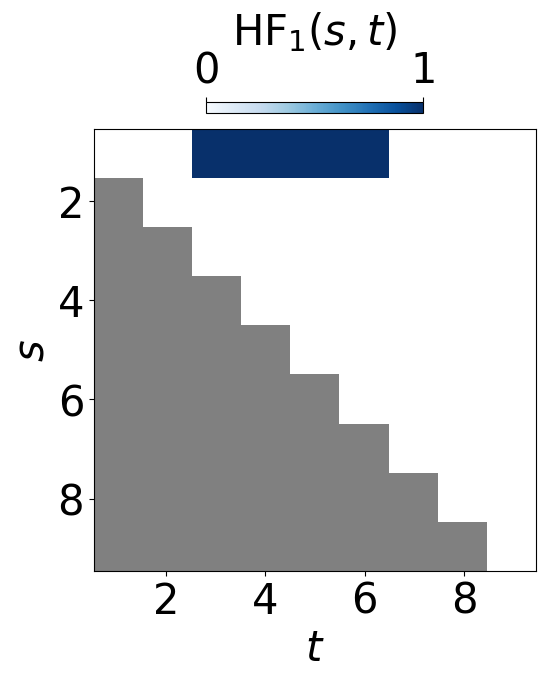

In [48]:
mcbif_results_backward = []
for i in range(len(tau_w)):
    print(f"\nProcessing backward partitions for tau_w = {tau_w[i]} ...")
    # initialise MCbiF
    mcbif = MCbiF(method="nerve")
    mcbif.load_data(partitions_backward[i], weeks+1)

    # run MCbiF
    mcbif_results_backward.append(mcbif.compute_all_measures(file_path=None, tqdm_disable=True))
    print("\nAverage 0-conflict:", round(mcbif.conflict_0_avg,3))

    # make plots
    mcbif.plot_hilbert_function(0)
    # mcbif.plot_conflict_0()
    mcbif.plot_hilbert_function(1)
    # mcbif.plot_conflict_1_diff()
    plt.show()


## Analyse MCbiF results over time

In [ ]:
# Optimal tau's identified by Bovet et al.
optimal_tau = [1,3,7]

We first analyse the average 0- and 1-conflict for different values of $\tau$.

In [39]:
c_0_bar = []
c_1_bar = []

for tau_id in range(len(tau_w)):

    c_0 = mcbif_results_forward[tau_id]["conflict_0_avg"]
    c_1 = mcbif_results_forward[tau_id]["conflict_1_avg"]

    c_0_bar.append(c_0)
    c_1_bar.append(c_1)

In [40]:
# We set a global configuration for matplotlib to obtain well-readable plots
SMALL_SIZE = 13
MEDIUM_SIZE = 13
BIGGER_SIZE = 13

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

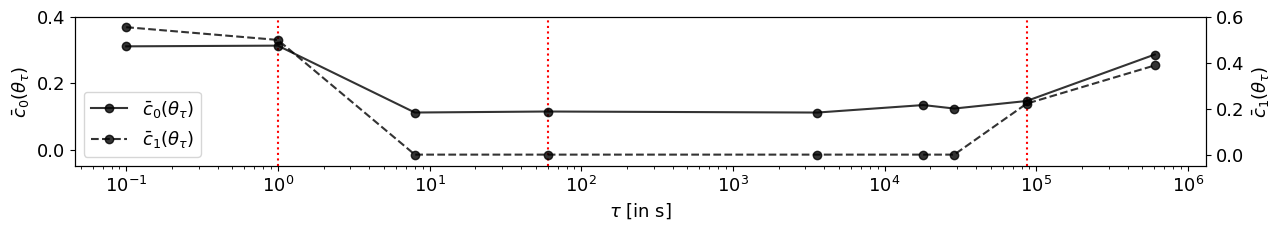

In [41]:
fig, ax = plt.subplots(figsize=(13, 2.5))
for tau in optimal_tau:
    ax.axvline(tau_w[tau], color="red", ls=":")
ax.plot(tau_w, c_0_bar, marker='o', label=r"$\bar c_0(\theta_\tau)$", alpha=0.8, color="black")
ax2 = ax.twinx()
ax2.set(ylabel=r"$\bar c_1(\theta_\tau)$",ylim=(-0.05,0.6))
ax2.plot(tau_w, c_1_bar, label=r"$\bar c_1(\theta_\tau)$", marker='o', alpha=0.8, color="black", ls="--")
ax.set(xscale='log', xlabel=r'$\tau$ [in s]', ylabel=r"$\bar c_0(\theta_\tau)$", ylim=(-0.05,0.4))
ax.legend()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='lower left')

plt.tight_layout()
plt.savefig("figures/persistent_conflict_forward.svg", bbox_inches="tight")

We next analyse the Hilbert distance between the MCbiF Hilbert functions of forward and backward sequences of partitions for different values of $\tau$.

In [32]:
dist_0_fb = []
dist_1_fb = []
for i in range(len(tau_w)):
    dist_0_fb.append(
        np.linalg.norm(mcbif_results_forward[i]["betti_0_rank"] - mcbif_results_backward[i]["betti_0_rank"])
    )
    dist_1_fb.append(
        np.linalg.norm(mcbif_results_forward[i]["betti_1_rank"] - mcbif_results_backward[i]["betti_1_rank"])
    )

In [33]:
# We set a global configuration for matplotlib to obtain well-readable plots
SMALL_SIZE = 17
MEDIUM_SIZE = 17
BIGGER_SIZE = 17

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

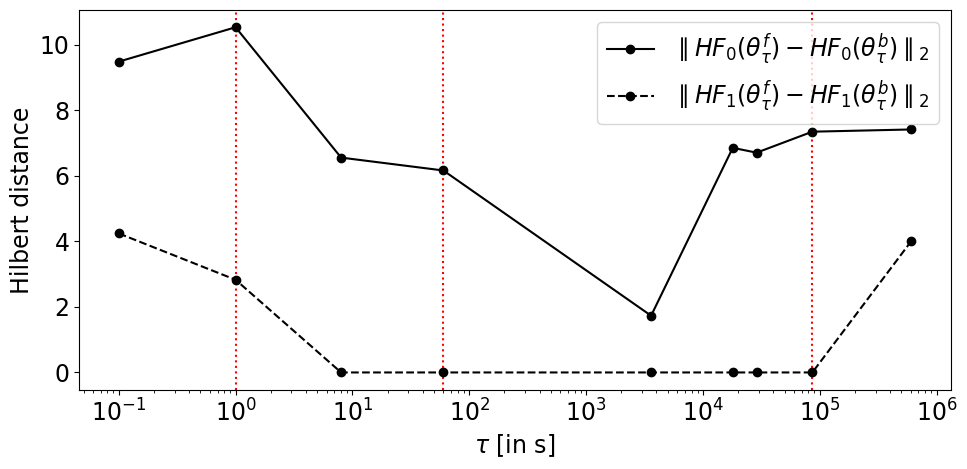

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
for tau in optimal_tau:
    ax.axvline(tau_w[tau], color="red", ls=":")
ax.plot(tau_w, dist_0_fb, label=r"$\parallel HF_0(\theta_\tau^f)-HF_0(\theta_\tau^b)\parallel_2$", marker='o', color="black")
ax.plot(tau_w, dist_1_fb, label=r"$\parallel HF_1(\theta_\tau^f)-HF_1(\theta_\tau^b)\parallel_2$", marker='o', color="black", ls="--")
ax.set(xscale='log', xlabel=r'$\tau$ [in s]', ylabel='Hilbert distance')
ax.legend()
plt.tight_layout()
plt.savefig("figures/distance_forward_backward.svg", bbox_inches="tight")

Finally, we compute the pairwise Hilbert distances for values $\tau, \tau'$.

In [35]:
pairwise_dist_0_f = np.zeros((len(tau_w), len(tau_w)))
pairwise_dist_1_f = np.zeros((len(tau_w), len(tau_w)))

pairwise_dist_0_b = np.zeros((len(tau_w), len(tau_w)))
pairwise_dist_1_b = np.zeros((len(tau_w), len(tau_w)))

for i in range(len(tau_w)):
    for j in range(len(tau_w)):
        pairwise_dist_0_f[i, j] = np.linalg.norm(
            mcbif_results_forward[i]["betti_0_rank"] - mcbif_results_forward[j]["betti_0_rank"]
        )
        pairwise_dist_1_f[i, j] = np.linalg.norm(
            mcbif_results_forward[i]["betti_1_rank"] - mcbif_results_forward[j]["betti_1_rank"]
        )

        pairwise_dist_0_b[i, j] = np.linalg.norm(
            mcbif_results_backward[i]["betti_0_rank"] - mcbif_results_backward[j]["betti_0_rank"]
        )
        pairwise_dist_1_b[i, j] = np.linalg.norm(
            mcbif_results_backward[i]["betti_1_rank"] - mcbif_results_backward[j]["betti_1_rank"]
        )

In [36]:
log10_tau_w = [rf"$10^{{{np.log10(tau):.1f}}}$" for tau in tau_w]
labels_tau = [f"$\\tau_{{{i+1}}}$" for i in range(len(tau_w))]

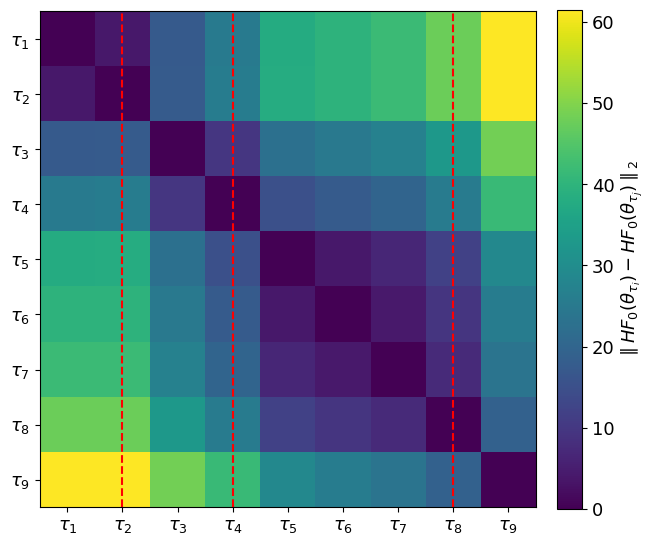

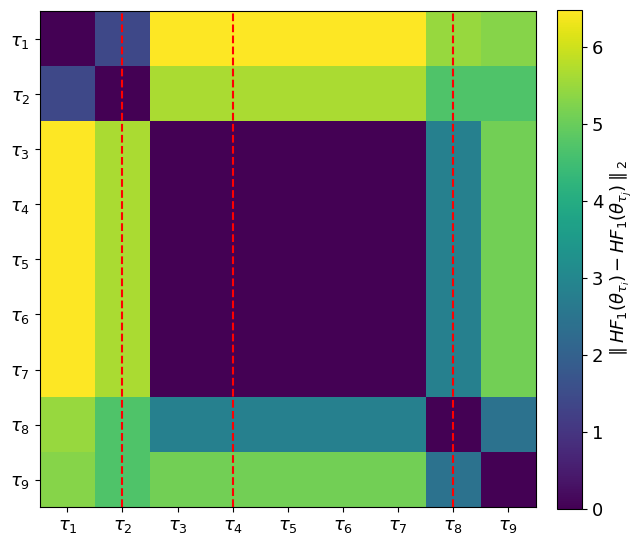

In [ ]:


fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(pairwise_dist_0_f, cmap='viridis', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"$\parallel HF_0(\theta_{\tau_i})-HF_0(\theta_{\tau_j})\parallel_2$")
ax.set_xticks(np.arange(len(tau_w)))
ax.set_yticks(np.arange(len(tau_w)))
ax.set_xticklabels(labels_tau)
ax.set_yticklabels(labels_tau)
for tau in optimal_tau:
    ax.axvline(tau, color="red", ls="--")
plt.savefig("figures/hf0_distance_forward.svg", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(pairwise_dist_1_f, cmap='viridis', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"$\parallel HF_1(\theta_{\tau_i})-HF_1(\theta_{\tau_j})\parallel_2$")
ax.set_xticks(np.arange(len(tau_w)))
ax.set_yticks(np.arange(len(tau_w)))
ax.set_xticklabels(labels_tau)
ax.set_yticklabels(labels_tau)
for tau in optimal_tau:
    ax.axvline(tau, color="red", ls="--")
plt.savefig("figures/hf1_distance_forward.svg", bbox_inches="tight")
plt.show()